# 04 — Protocole orthostatique

Le **test orthostatique** mesure la réponse du système nerveux autonome au changement
de posture : allongé → debout. Une réponse saine implique :
- Une augmentation du rythme cardiaque de **10–25 bpm** (trop peu = dysautonomie, trop = POTS)
- Une chute du HF de **30–60 %** (retrait vagal normal)
- Un retour à la normale en **1–3 minutes**

**Deux scores complémentaires (v0.2.4) :**

| Score | Nature | Ce qu'il mesure |
|---|---|---|
| `autonomic_score` | Absolu (0–100) | Qualité de la réponse ΔHR + retrait vagal HF — sans baseline |
| `readiness_score` | Relatif (0–100) | Niveau de récupération supine vs baseline personnelle — comme le resting |

Utiliser les deux ensemble : l'autonomic_score détecte les anomalies de réponse ;
le readiness_score suit la fatigue journalière.

In [1]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("../.env"))

import matplotlib.pyplot as plt

import cardiolab
from cardiolab.analytics import (
    Baseline,
    orthostatic_readiness_score,
    orthostatic_score,
)
from cardiolab.database import HRVRepository
from cardiolab.labels import LABELS_FR
from cardiolab.protocols import orthostatic_hrv
from cardiolab.reporting import table_orthostatic_comparison
from cardiolab.sensors_tools.polar import parse_rr_file
from cardiolab.signals.rr import RRSeries
from cardiolab.visualization.orthostatic_plots import (
    plot_orthostatic_dual_score_evolution,
    plot_orthostatic_phases_evolution,
)

DATASETS_DIR = Path(cardiolab.__file__).parent / "datasets"
USER_ID = "demo-user"
print("✓  OK")

✓  OK


## Voie A — Depuis un fichier

Analyse d'une session orthostatique depuis le fichier `.txt` disponible dans les datasets.

In [2]:
filepath = sorted((DATASETS_DIR / "raw" / "orthostatic").glob("*.txt"))[0]
raw = parse_rr_file(filepath)
rr = RRSeries(raw["rr_intervals"])
result = orthostatic_hrv(rr)

supine = result.phases.supine.features
standing = result.phases.standing.features

print(f"Session : {filepath.stem}")
print(f"Interprétation : {result.interpretation}")
print()
print("─── Réponse orthostatique ────────────────────")
print(f"  ΔHR              : {result.hr_response:+.1f} bpm  (normal 10–25 bpm)")
print(f"  HF drop %        : {result.hf_response_pct:+.1f} %  (normal −30 % à −60 %)")
print(
    f"  LF/HR % change   : {result.lf_hr_pct_change:+.1f} %  "
    f"(normal > 30 % = activation sympathique saine)"
)
print(
    f"  ΔRMSSD           : {result.delta_rmssd:+.1f} ms  "
    f"(normal < −15 ms = bon retrait vagal)"
)
print()
print("─── Phases HRV ──────────────────────────────")
print(f"  Supine  RMSSD : {supine.rmssd:.1f} ms  |  HR : {supine.mean_hr:.1f} bpm")
print(f"  Debout  RMSSD : {standing.rmssd:.1f} ms  |  HR : {standing.mean_hr:.1f} bpm")

# Scores
auto_score = orthostatic_score(result.hr_response, result.hf_response_pct)
print(f"\n  Autonomic score : {auto_score:.0f}/100")

Session : 2026-05-17 09-29-27
Interprétation : normal

─── Réponse orthostatique ────────────────────
  ΔHR              : +25.5 bpm  (normal 10–25 bpm)
  HF drop %        : +96.4 %  (normal −30 % à −60 %)
  LF/HR % change   : -82.5 %  (normal > 30 % = activation sympathique saine)
  ΔRMSSD           : +86.6 ms  (normal < −15 ms = bon retrait vagal)

─── Phases HRV ──────────────────────────────
  Supine  RMSSD : 100.9 ms  |  HR : 55.7 bpm
  Debout  RMSSD : 14.3 ms  |  HR : 81.1 bpm

  Autonomic score : 49/100


/home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/cardiolab/protocols/orthostatic.py:500: PhysiologicalWarning: Recording duration (20 s) is below the recommended minimum of 300 s for resting HRV analysis. Frequency-domain and non-linear metrics may be unreliable.
  features=resting_hrv(transition_rr, method=method),
/home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/cardiolab/protocols/orthostatic.py:507: PhysiologicalWarning: Recording duration (281 s) is below the recommended minimum of 300 s for resting HRV analysis. Frequency-domain and non-linear metrics may be unreliable.
  features=resting_hrv(standing_rr, method=method),


## Tableau de comparaison supine vs debout

In [3]:
styler = table_orthostatic_comparison([result], labels=LABELS_FR)
display(styler)

/home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/.venv/lib/python3.12/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


## Voie B — Depuis la base

Charger l'historique orthostatique, calculer les deux scores et afficher l'évolution.

In [4]:
with HRVRepository.from_env() as repo:
    ortho_history = repo.load_orthostatic(USER_ID)

if not ortho_history:
    print("⚠️  Aucune session orthostatique en base — exécutez d'abord le notebook 02")
else:
    print(f"{len(ortho_history)} sessions chargées")

    # Calculer les deux scores
    baseline = Baseline()
    readiness_scores = []
    auto_scores = []

    for rec in ortho_history:
        # readiness_score — relatif, vs baseline supine
        rs = orthostatic_readiness_score(rec.supine, baseline)
        readiness_scores.append(rs)
        baseline.history.append(rec.supine)

        # autonomic_score — absolu, réponse ΔHR + HF
        as_ = orthostatic_score(rec.hr_response, rec.hf_response_pct)
        auto_scores.append(as_)

    dates = [str(rec.date) for rec in ortho_history]

    print(f"\n{'Date':<12} {'Readiness':>10} {'Autonomic':>10} {'ΔHR':>8} Interp.")
    print("-" * 60)
    for rec, rs, as_ in zip(ortho_history, readiness_scores, auto_scores, strict=False):
        print(
            f"  {str(rec.date):<10}  {rs:>8.0f}/100  {as_:>8.0f}/100  "
            f"{rec.hr_response:>+6.1f} bpm  {rec.interpretation}"
        )

1 sessions chargées

Date          Readiness  Autonomic      ΔHR Interp.
------------------------------------------------------------
  2026-05-17        50/100        49/100   +25.5 bpm  normal


## Évolution des deux scores dans le temps

/home/jmilon/Projet-Pro-DevSecOps/Programmation/GitLab/cardioanalysis/cardiolab/cardiolab/visualization/orthostatic_plots.py:491: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


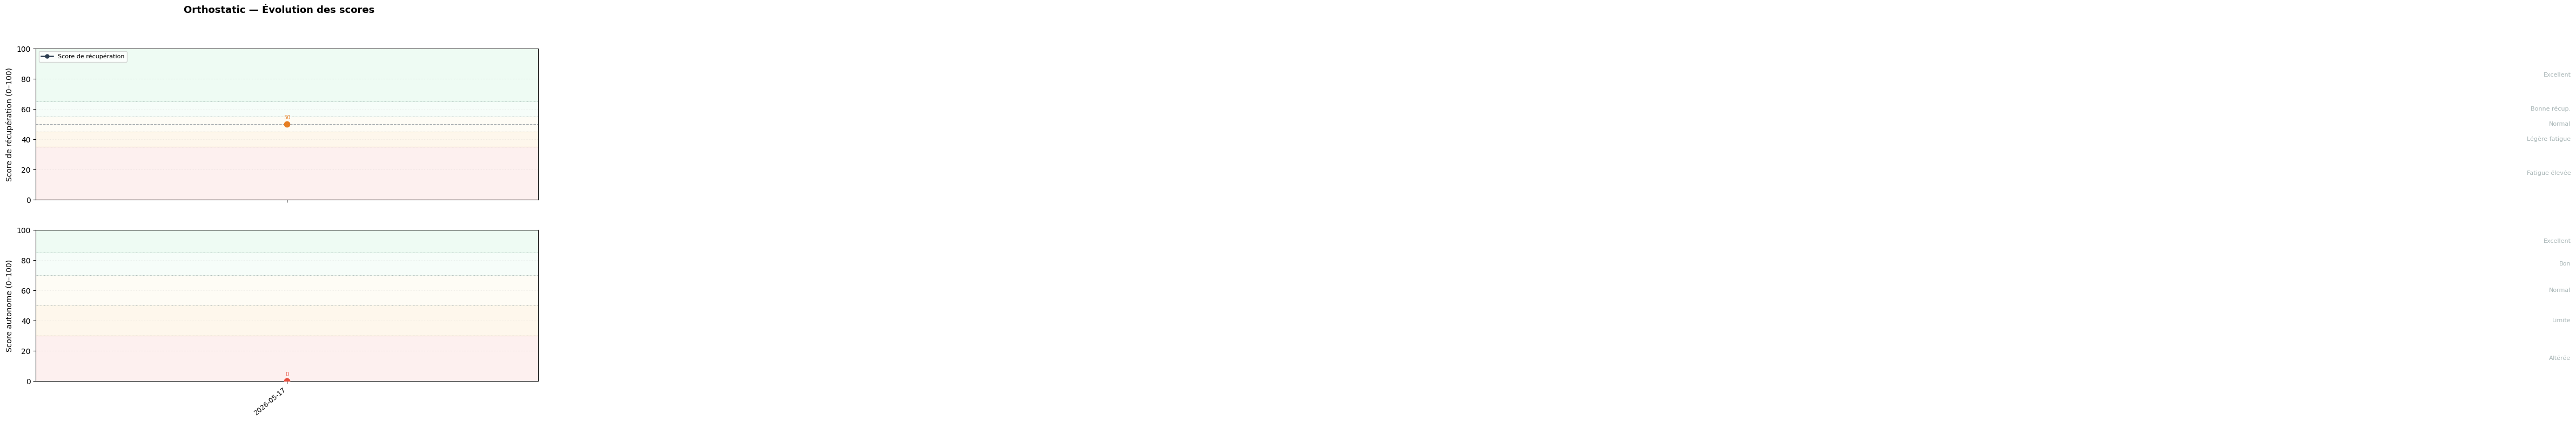

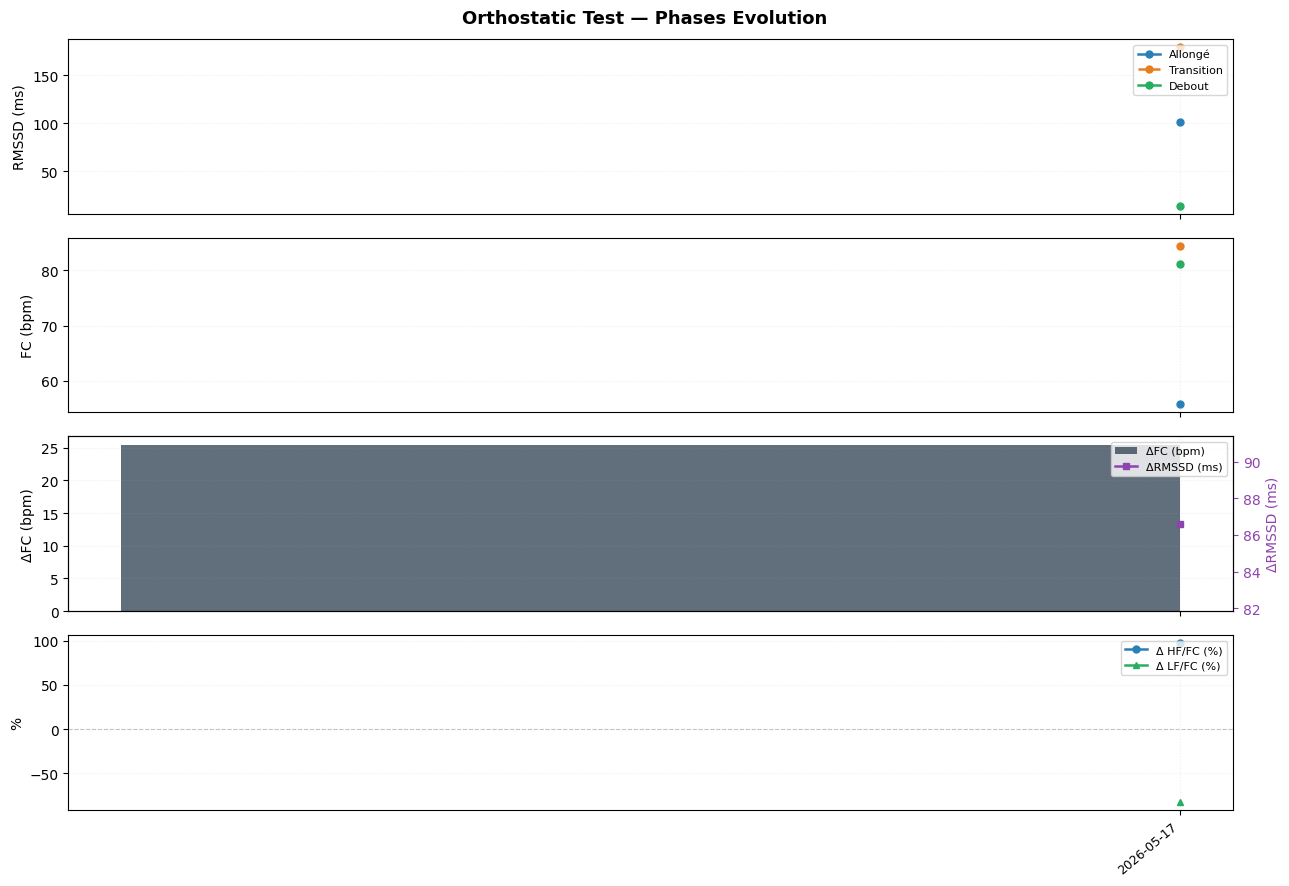

In [5]:
if ortho_history:
    fig = plot_orthostatic_dual_score_evolution(
        ortho_history,
        readiness_scores=readiness_scores,
        session_labels=dates,
        labels=LABELS_FR,
    )
    plt.show()

    fig = plot_orthostatic_phases_evolution(
        ortho_history,
        session_labels=dates,
        labels=LABELS_FR,
    )
    plt.show()